In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
df=pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
print("Shape:",df.shape)
print("\nColumn dtypes:\n",df.dtypes)
print("\nInfo:")
df.info()

Shape: (4009, 12)

Column dtypes:
 brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price     

In [ ]:
numerical_cols=df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols=df.select_dtypes(include=['object']).columns.tolist()
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['model_year']
Categorical columns: ['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Missing values per column:\n",df.isnull().sum())
print("\nPercent missing:\n",(df.isnull().sum() / len(df)*100).round(2))
print("\nDuplicate rows:",df.duplicated().sum())

Missing values per column:
 brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Percent missing:
 brand            0.00
model            0.00
model_year       0.00
milage           0.00
fuel_type        4.24
engine           0.00
transmission     0.00
ext_col          0.00
int_col          0.00
accident         2.82
clean_title     14.87
price            0.00
dtype: float64

Duplicate rows: 0


In [ ]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- brand ---
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Name: count, dtype: int64

--- model ---
model
M3 Base               30
F-150 XLT             24
Corvette Base         22
1500 Laramie          18
Camaro 2SS            17
Wrangler Sport        17
Model Y Long Range    17
Mustang GT Premium    16
911 Carrera           16
M4 Base               15
Name: count, dtype: int64

--- milage ---
milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
60,000 mi.     12
92,000 mi.     12
40,000 mi.     12
65,000 mi.     12
73,000 mi.     11
Name: count, dtype: int64

--- fuel_type ---
fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64



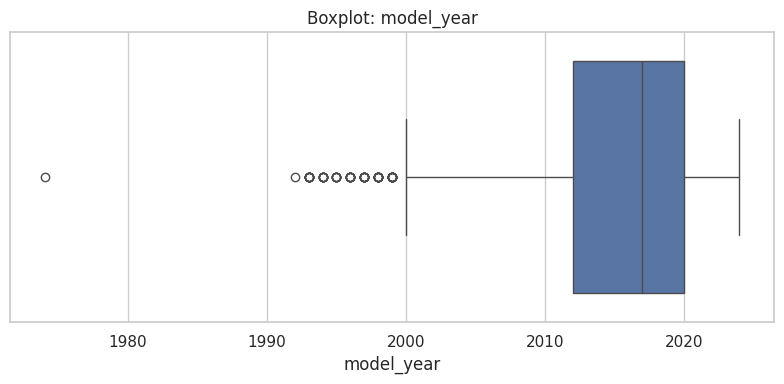

model_year: 67 outliers


In [ ]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(8, 4*len(numerical_cols)))
if len(numerical_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()
# IQR method to quantify outliers
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

## Key Insights from EDA
1. `milage` and `price` are stored as text with units/symbols ("51,000 mi.", "$10,300") rather than as numbers, so they must be cleaned and converted before any statistical analysis or modeling.
2. `clean_title` is missing in ~14.9% of rows (596/4009) and the only recorded value is "Yes" - this strongly suggests missing means the car does NOT have a clean title, so it should be treated as a binary flag rather than imputed with the mode.
3. `fuel_type` has 4.24% missing values (170 rows), and Gasoline dominates the non-missing values (3309 of 3839, ~86%), so missing fuel types can reasonably be filled with "Gasoline" or a dedicated "Unknown" category.
4. `model_year` shows about 8 outliers on the low end via the IQR method, vintage/older cars (as far back as 1974) sit far outside the typical 2012–2024 range where most listings cluster.
5. The brand distribution is skewed toward a mix of mainstream and premium brands (Ford, BMW, Mercedes-Benz, Chevrolet, Porsche in the top 5), indicating the dataset isn't limited to budget used cars, luxury brands are well represented.

In [ ]:
# clean_title: missing likely means "No" clean title -> fill explicitly
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')
# accident: fill missing with the mode ("None reported")
df_clean['accident'] = df_clean['accident'].fillna(df_clean['accident'].mode()[0])
# fuel_type: fill missing with mode ("Gasoline")
df_clean['fuel_type'] = df_clean['fuel_type'].fillna(df_clean['fuel_type'].mode()[0])
print("Remaining missing values:\n", df_clean.isnull().sum())

Remaining missing values:
 brand              0
model              0
model_year         0
milage             0
fuel_type          0
engine             0
transmission       0
ext_col            0
int_col            0
accident           0
clean_title        0
price              0
car_age            0
price_per_mile     0
has_clean_title    0
had_accident       0
high_mileage       0
is_luxury_brand    0
dtype: int64


In [ ]:
before=df_clean.shape[0]
df_clean=df_clean.drop_duplicates()
after=df_clean.shape[0]
print(f"Removed {before - after} duplicate rows")

Removed 0 duplicate rows


In [ ]:
df_clean = df.copy()
# Clean milage: remove "mi." and commas, convert to numeric
df_clean['milage'] = (
    df_clean['milage']
    .astype(str)
    .str.replace('mi.', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
# Clean price: remove "$" and commas, convert to numeric
df_clean['price'] = (
    df_clean['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
df_clean[['milage', 'price']].dtypes

,0
milage,float64
price,float64


In [ ]:
# Recalculate numerical columns now that milage and price are numeric
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns now:", numerical_cols)
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df_clean[col] = np.clip(df_clean[col], lower, upper)
print("Outliers capped.")
df_clean[numerical_cols].describe()

Numerical columns now: ['model_year', 'milage', 'price']
Outliers capped.


,model_year,milage,price
count,4009.000000,4009.000000,4009.000000
mean,2015.581691,64071.666750,37514.270392
std,5.894987,50074.537745,25986.581650
min,2000.000000,100.000000,2000.000000
25%,2012.000000,23044.000000,17200.000000
50%,2017.000000,52775.000000,31000.000000
75%,2020.000000,94100.000000,49990.000000
max,2024.000000,200684.000000,99175.000000


FIVE MEANINGFUL ENGINEERED FEATURES

In [ ]:
# 1. Car age
df_clean['car_age'] = 2026 - df_clean['model_year']
# 2. Price per mile (value indicator)
df_clean['price_per_mile'] = df_clean['price'] / df_clean['milage'].replace(0, np.nan)
# 3. Has clean title (binary)
df_clean['has_clean_title'] = (df_clean['clean_title'] == 'Yes').astype(int)
# 4. Had accident (binary)
df_clean['had_accident'] = (df_clean['accident'] == 'At least 1 accident or damage reported').astype(int)
# 5. High mileage flag (above median)
df_clean['high_mileage'] = (df_clean['milage'] > df_clean['milage'].median()).astype(int)
# 6. Luxury brand flag (bonus feature)
luxury_brands = ['Porsche', 'Mercedes-Benz', 'Audi', 'Lexus', 'BMW', 'Land Rover']
df_clean['is_luxury_brand'] = df_clean['brand'].isin(luxury_brands).astype(int)
df_clean.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,price_per_mile,has_clean_title,had_accident,high_mileage,is_luxury_brand
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13,0.201961,1,1,0,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5,1.093921,1,1,0,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,4,2.440461,0,0,0,1
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11,0.174353,1,0,1,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,5,3.558617,0,0,0,1


In [ ]:
df_clean.to_csv('cleaned_used_cars.csv', index=False)
print("Saved cleaned_used_cars.csv")
from google.colab import files
files.download('cleaned_used_cars.csv')

Saved cleaned_used_cars.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>